# Short Stratify / Training Pipeline
Lightweight version: keep selected metadata fields, remove only empty/repeated transcripts, chart the split, and export training datasets from original transcripts.

In [1]:
import os
import re
import csv
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

## Config

In [2]:
# Configuration options
dataset = "briggs-v-elliot"  # example: briggs-v-elliot, 
dataset_cap = dataset.capitalize()
save_files = True
view_dataframes = True

# Only fields actually used by this pipeline.
required_fields = [
    "SSID",
    "Title",
    "Description",
    "Date",
    "Transcript",
]

In [3]:
def save_csv(df, title):
    df.to_csv(
        title,
        index=False,
        encoding="utf-8",
        quoting=csv.QUOTE_NONNUMERIC,
        escapechar="\\",
        lineterminator="\n",
    )

parent = Path(f"../data/{dataset}")
original_dir = parent / "original_data"

# Match original project-style dataset path handling first, then fall back to discovery.
if dataset == "eaadams":
    default_csv = original_dir / f"{dataset_cap} metadata_with_transcripts.csv"
elif dataset == "briggs-v-elliot":
    default_csv = original_dir / "briggs_v_elliot-220313.csv"
else:
    default_csv = original_dir / f"{dataset_cap} metadata.csv"

default_xlsx = original_dir / f"{dataset_cap} metadata.xlsx"

if default_csv.exists():
    source_file = default_csv
    df_raw = pd.read_csv(source_file)
elif default_xlsx.exists():
    source_file = default_xlsx
    df_raw = pd.read_excel(source_file)
else:
    csv_candidates = sorted(original_dir.glob("*metadata*.csv")) + sorted(original_dir.glob("*.csv"))
    xlsx_candidates = sorted(original_dir.glob("*metadata*.xlsx")) + sorted(original_dir.glob("*.xlsx"))
    if csv_candidates:
        source_file = csv_candidates[0]
        df_raw = pd.read_csv(source_file)
    elif xlsx_candidates:
        source_file = xlsx_candidates[0]
        df_raw = pd.read_excel(source_file)
    else:
        raise FileNotFoundError(f"No CSV/XLSX metadata file found under {original_dir}")

# Normalize transcript source across dataset variants.
if "Transcript" not in df_raw.columns:
    if "Transcription" in df_raw.columns:
        df_raw["Transcript"] = df_raw["Transcription"]
    elif "Original Transcript" in df_raw.columns:
        df_raw["Transcript"] = df_raw["Original Transcript"]
    else:
        df_raw["Transcript"] = ""

# Ensure SSID is present; map from common id columns if needed.
if "SSID" not in df_raw.columns:
    for candidate in ["CONTENTdm number", "Identifier", "id", "ID"]:
        if candidate in df_raw.columns:
            df_raw["SSID"] = df_raw[candidate]
            break
    if "SSID" not in df_raw.columns:
        df_raw["SSID"] = df_raw.index.astype(str)

# Keep only required fields and create missing fields as empty strings.
for col in required_fields:
    if col not in df_raw.columns:
        df_raw[col] = ""

df = df_raw[required_fields].copy()

# Normalize transcript and derive Year for training outputs.
df["Transcript"] = df["Transcript"].fillna("").astype(str).str.strip()
df["Year"] = df["Date"].astype(str).apply(lambda x: re.sub(r"[^0-9]+", "", x)[:4])

print(f"Source file: {source_file}")
print(f"Rows loaded: {len(df)}")
print(f"Columns kept: {len(df.columns)}")
if view_dataframes:
    display(df.head(3))

Source file: ../data/briggs-v-elliot/original_data/briggs_v_elliot-220313.csv
Rows loaded: 23
Columns kept: 6


,SSID,Title,Description,Date,Transcript,Year
0,42003054,Letter from South Carolina Conference of NAACP...,Letter from the South Carolina Conference of t...,1951-11-24,,1951
1,42003097,Why Does Your Community Need a Citizens' Council?,Pamphlet advocating for the formation of Citiz...,undated,,
2,42003093,Letter from L. B. McCord to W. O. McElveen reg...,"Letter from L. B. McCord, Superintendent of Ed...",1957-12-11,,1957


In [4]:
# Isolate empty and repeated transcripts only (no CPD rules).
empty_mask = (df["Transcript"] == "") | (df["Transcript"] == "[ EMPTY TRANSCRIPT]")
df_empty = df[empty_mask].copy()
df_non_empty = df[~empty_mask].copy()

df_repeated = df_non_empty[df_non_empty.duplicated(subset=["Transcript"], keep=False)].copy()
df_main = df_non_empty.drop_duplicates(subset=["Transcript"], keep="first").copy()

print(f"Empty transcripts: {len(df_empty)}")
print(f"Repeated transcripts: {len(df_repeated)}")
print(f"Usable main rows: {len(df_main)}")

if save_files:
    split_dir = parent / "split_data" / "h1_split"
    split_dir.mkdir(parents=True, exist_ok=True)
    save_csv(df_empty, split_dir / f"D_{dataset[0:3]}_empty_transcripts.csv")
    save_csv(df_repeated, split_dir / f"D_{dataset[0:3]}_repeated_transcripts.csv")
    save_csv(df_main, split_dir / f"D_{dataset[0:3]}_h1_main.csv")

Empty transcripts: 23
Repeated transcripts: 0
Usable main rows: 0


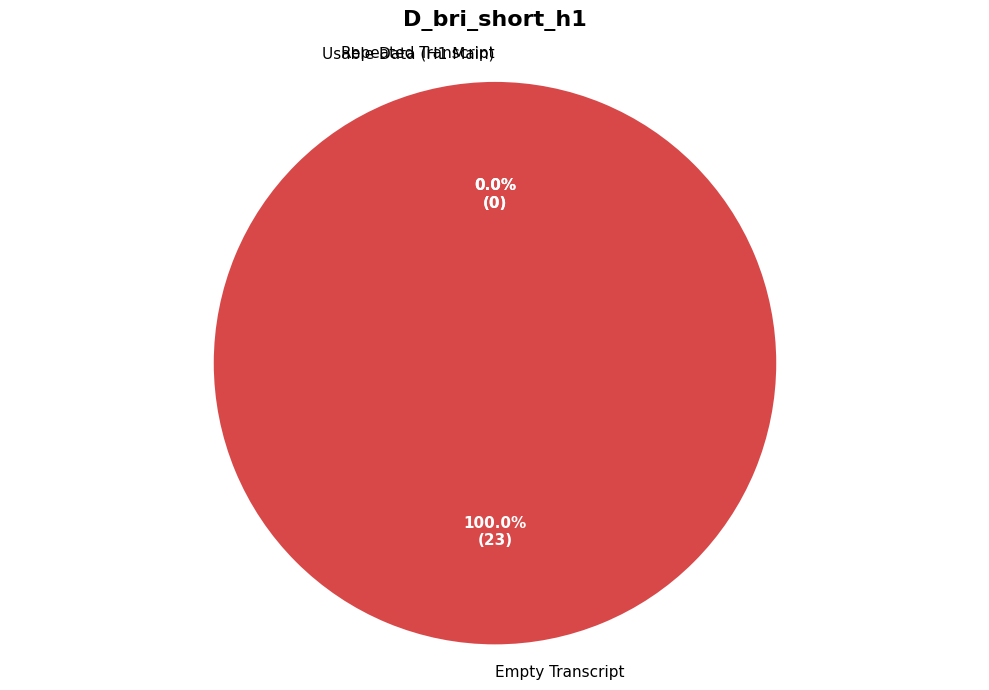

In [ ]:
# Data split chart
categories = ["Empty Transcript", "Repeated Transcript", "Usable Data (H1 Main)"]
values = [len(df_empty), len(df_repeated), len(df_main)]

fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    autopct=lambda pct: f"{pct:.1f}%\n({int(pct/100.*sum(values))})",
    startangle=90,
    colors=["#d94848", "#3d85c6", "#e69138"],
    textprops={"fontsize": 11},
)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

plt.title(f"D_{dataset[0:3]}", fontsize=16, fontweight="bold", pad=20)
ax.axis("equal")
plt.tight_layout()

if save_files:
    assets_dir = parent / "assets"
    assets_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(assets_dir / f"D_{dataset[0:3]}_pie.png", dpi=300, bbox_inches="tight")

plt.show()

In [6]:
# Training exports (original transcript only; no cleaned versions)
def create_text_field(row, fields):
    parts = []
    for field in fields:
        if field in row and pd.notna(row[field]) and str(row[field]).strip():
            parts.append(f"[{field}]: \"{str(row[field]).strip()}\"")
    return "\n".join(parts)

train_df = df_main.copy()
output_dir = parent / "training" / "original"
output_dir.mkdir(parents=True, exist_ok=True)

# 1) Title + Description + Date
title_description = train_df.copy()
title_description["text"] = title_description.apply(
    lambda row: create_text_field(row, ["Title", "Description", "Date"]), axis=1
)
title_description = title_description[["SSID", "Year", "text"]].copy()

# 2) Transcript only
tr_only = train_df.copy()
tr_only["text"] = tr_only["Transcript"].fillna("").astype(str)
tr_only = tr_only[["SSID", "Year", "text"]].copy()

# 3) Title + Description + Date + Transcript
all_meta = train_df.copy()
all_meta["text"] = all_meta.apply(
    lambda row: (
        create_text_field(row, ["Title", "Description", "Date"])
        + f"\n[Transcript]: \"{str(row['Transcript']).strip()}\""
    ) if str(row["Transcript"]).strip() else create_text_field(row, ["Title", "Description", "Date"]),
    axis=1
)
all_meta = all_meta[["SSID", "Year", "text"]].copy()

title_desc_path = output_dir / f"D_{dataset[0:3]}_h2_title_description_date.csv"
tr_only_path = output_dir / f"D_{dataset[0:3]}_h2_transcript_only.csv"
all_meta_path = output_dir / f"D_{dataset[0:3]}_h2_all_metadata.csv"

title_description.to_csv(title_desc_path, index=False)
tr_only.to_csv(tr_only_path, index=False)
all_meta.to_csv(all_meta_path, index=False)

print("\n=== DATASETS SAVED ===")
print(f"- Title + Description + Date: {title_desc_path}")
print(f"- Transcript only: {tr_only_path}")
print(f"- All metadata: {all_meta_path}")

if view_dataframes:
    display(train_df.head(3))


=== DATASETS SAVED ===
- Title + Description + Date: ../data/briggs-v-elliot/training/original/D_bri_h2_title_description_date.csv
- Transcript only: ../data/briggs-v-elliot/training/original/D_bri_h2_transcript_only.csv
- All metadata: ../data/briggs-v-elliot/training/original/D_bri_h2_all_metadata.csv


,SSID,Title,Description,Date,Transcript,Year
